In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

:::{admonition} Download
:class: important render-all

This notebook can be downloaded as **{nb-download}`02_01_place_cells_1d_neural_tuning.ipynb`**. See the button at the top right to download as markdown or pdf.
:::

# Data wrangling, 1D neural tuning, and model fitting

<div class="render-all">
    
In this series of notebooks, we will review more advanced applications of pynapple; tuning curves, signal processing, and decoding; as well as fitting GLMs to the data using NeMoS. We'll apply these methods to demonstrate and visualize some well-known physiological properties of hippocampal activity, specifically phase presession of place cells and sequential coordination of place cell activity during theta oscillations.

This series is split into 4 notebooks:
1. (This notebook) Data wrangling, 1D neural tuning, and model fitting
2. Signal processing
3. 2D neural tuning and model fitting
4. Neural decoding

You should start by completing this first notebook. Afterwards, you can choose any notebook that looks most interesting to you!

</div>

In [2]:
import workshop_utils
# imports
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy as sp
import seaborn as sns
import tqdm
import pynapple as nap

# necessary for animation
import nemos as nmo
plt.style.use(nmo.styles.plot_style)

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

## Part 1: Data wrangling
### Fetching the data

<div class="render-all">  
    
The data set we'll use is from the study [Diversity in neural firing dynamics supports both rigid and learned hippocampal sequences](https://www.science.org/doi/10.1126/science.aad1935). In this study, the authors collected electrophisiology data from layer CA1 of hippocampus in rats. In each recording session, data were collected while the rats explored a novel environment (a linear or circular track), as well as during sleep before and after exploration. In our following analyses, we'll focus on the exploration period of a single rat and recording session.

The full dataset for this study can be accessed on [DANDI](https://dandiarchive.org/dandiset/000044/0.210812.1516) and a smaller file containing only the session and data of interest can be found at [OSF](https://osf.io/2dfvp). Both datasets are saved as [NWB](https://www.nwb.org) files.

</div>

In [3]:
# fetch file path
path = workshop_utils.fetch_data("Achilles_10252013_EEG.nwb")
# load data with pynapple
data = nap.load_file(path)
print(data)

Achilles_10252013_EEG
┍━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys        │ Type        │
┝━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units       │ TsGroup     │
│ rem         │ IntervalSet │
│ nrem        │ IntervalSet │
│ forward_ep  │ IntervalSet │
│ eeg         │ TsdFrame    │
│ theta_phase │ Tsd         │
│ position    │ Tsd         │
┕━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


<div class="render-all">  
    
This gives us a dictionary of pynapple objects that have been extracted from the NWB file. Let's explore each of these objects.

</div>

:::{admonition} Note
:class: note render-all
We will ignore the object `theta_phase` because we will be computing this ourselves in a separate notebook.
:::


#### units

<div class="render-all">  
    
The `units` field is a [`TsGroup`](https://pynapple.org/generated/pynapple.TsGroup.html#pynapple.TsGroup), where each unit has the following metadata:
- **rate**: computed by pynapple, is the average firing rate of the neuron across all recorded time points.
- **location**, **shank**, and **cell_type**: variables saved and imported from the original data set.

</div>

In [4]:
data["units"]

Index    rate     location    shank    cell_type
-------  -------  ----------  -------  -----------
1        1.56775  ca1         1        pE
2        9.12029  ca1         1        pI
6        0.14618  ca1         1        pE
7        1.40307  ca1         1        pE
9        0.22848  ca1         1        pE
11       0.4157   ca1         1        pE
12       1.57063  ca1         1        pE
...      ...      ...         ...      ...
266      0.6839   ca1         13       pE
267      3.0145   ca1         13       pI
268      0.86567  ca1         13       pE
269      0.28607  ca1         13       pE
270      0.30931  ca1         13       pE
271      0.35912  ca1         13       pE
272      0.62102  ca1         13       pE

#### rem, nrem, and forward_ep

<div class="render-all">  

The next three objects; `rem`, `nrem`, and `forward_ep`; are all [`IntervalSet`](https://pynapple.org/generated/pynapple.IntervalSet.html#pynapple.IntervalSet) objects containing time windows of REM sleep, nREM sleep, and forward runs down the linear maze, respectively. 

</div>

In [5]:
data["rem"]

  index    start    end
      0    13747  13934
      1    15963  15991
      2    16035  16214
      3    22521  22573
shape: (4, 2), time unit: sec.

In [6]:
data["nrem"]

  index    start    end
      0    12892  13746
      1    13971  15963
      2    15991  16034
      3    16241  16565
      4    16837  16874
      5    17059  18076
      6    21350  21399
      7    22068  22520
      8    22635  22745
      9    24326  24419
     10    24953  25547
shape: (11, 2), time unit: sec.

In [7]:
data["forward_ep"]

index    start            end
0        18193.598802655  18197.489989104
1        18198.437185805  18201.30437582
2        18240.625838885  18243.083430326
3        18273.95692281   18276.414514252
4        18315.940776603  18318.244768579
5        18347.377467126  18347.761465788
6        18350.193457319  18350.500656249
...      ...              ...
77       19848.786638518  19856.133812932
78       19903.903246576  19904.056846041
79       19954.693469701  19956.587863104
80       19979.422983581  19987.794154429
81       20050.155537258  20052.664328521
82       20072.504259429  20080.465831703
83       20123.217682821  20123.396882197
shape: (84, 2), time unit: sec.

<div class="render-all"> 

The following plot demonstrates how each of these labelled epochs are organized across the session.

</div>

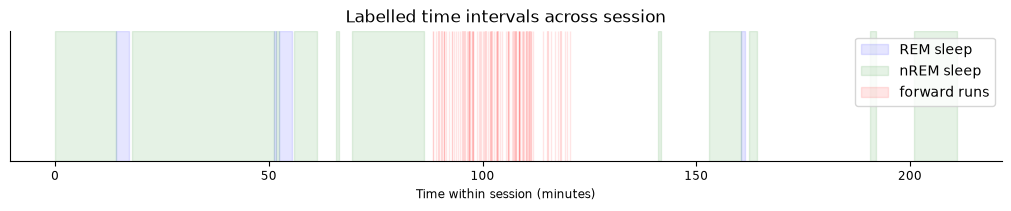

In [8]:
t_start = data["nrem"].start[0]
fig,ax = plt.subplots(figsize=(10,2), constrained_layout=True)
sp1 = [ax.axvspan((iset.start[0]-t_start)/60, (iset.end[0]-t_start)/60, color="blue", alpha=0.1) for iset in data["rem"]];
sp2 = [ax.axvspan((iset.start[0]-t_start)/60, (iset.end[0]-t_start)/60, color="green", alpha=0.1) for iset in data["nrem"]];
sp3 = [ax.axvspan((iset.start[0]-t_start)/60, (iset.end[0]-t_start)/60, color="red", alpha=0.1) for iset in data["forward_ep"]];
ax.set(xlabel="Time within session (minutes)", title="Labelled time intervals across session", yticks=[])
ax.legend([sp1[0],sp2[0],sp3[0]], ["REM sleep","nREM sleep","forward runs"]);

#### eeg

<div class="render-all">  

The `eeg` object is a [`TsdFrame`](https://pynapple.org/generated/pynapple.TsdFrame.html#pynapple.TsdFrame) containing an LFP voltage trace for a single representative channel in CA1.

</div>

In [9]:
data["eeg"]

Time (s)    1
----------  ----------
12679.5     -258
12679.5008  -341
12679.5016  -355
12679.5024  -379
12679.5032  -364
12679.504   -406
12679.5048  -508
...
25546.9696  2035
25546.9704  2021
25546.9712  2023
25546.972   1906
25546.9728  1848
25546.9736  1862
25546.9744  1976
Metadata
location    ca1
group_name  group1_ca1
...         ...
dtype: int16, shape: (16084344, 1)

<div class="render-all">  

Despite having a single column, this [`TsdFrame`](https://pynapple.org/generated/pynapple.TsdFrame.html#pynapple.TsdFrame) is still a 2D object. We can represent this as a 1D `Tsd` by indexing into the first column.

</div>

In [10]:
data["eeg"][:,0]

Time (s)
----------  ----
12679.5     -258
12679.5008  -341
12679.5016  -355
12679.5024  -379
12679.5032  -364
12679.504   -406
12679.5048  -508
...
25546.9696  2035
25546.9704  2021
25546.9712  2023
25546.972   1906
25546.9728  1848
25546.9736  1862
25546.9744  1976
dtype: int16, shape: (16084344,)

#### position

<div class="render-all">  

The final object, `position`, is a [`Tsd`](https://pynapple.org/generated/pynapple.Tsd.html#pynapple.Tsd) containing the linearized position of the animal, in centimeters, recorded during the exploration window.

</div>

In [11]:
data["position"]

Time (s)
---------------  ---
18079.5          nan
18079.525599911  nan
18079.551199822  nan
18079.576799733  nan
18079.602399643  nan
18079.627999554  nan
18079.653599465  nan
...
20146.820800624  nan
20146.846400535  nan
20146.872000446  nan
20146.897600357  nan
20146.923200267  nan
20146.948800178  nan
20146.974400089  nan
dtype: float64, shape: (80762,)

<div class="render-all">  

Positions that are not defined, i.e. when the animal is at rest, are filled with `NaN`.

This object additionally contains a [`time_support`](https://pynapple.org/generated/pynapple.Tsd.html#id1) attribute, which gives the time interval during which positions are recorded (including points recorded as `NaN`).

</div>

In [12]:
data["position"].time_support

  index    start    end
      0  18079.5  20147
shape: (1, 2), time unit: sec.

<div class="render-all">  

Let's visualize the first 300 seconds of position data and overlay `forward_ep` intervals.

</div>

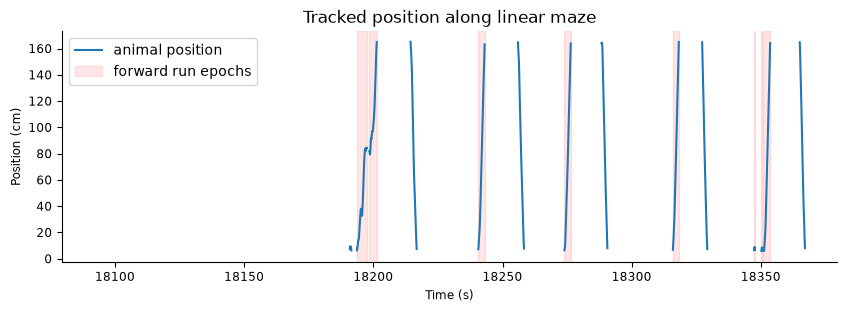

In [13]:
pos_start = data["position"].time_support.start[0]
fig, ax = plt.subplots(figsize=(10,3))
l1 = ax.plot(data["position"])
l2 = [ax.axvspan(iset.start[0], iset.end[0], color="red", alpha=0.1) for iset in data["forward_ep"]];
ax.set(xlim=[pos_start,pos_start+300], ylabel="Position (cm)", xlabel="Time (s)", title="Tracked position along linear maze")
ax.legend([l1[0], l2[0]], ["animal position", "forward run epochs"])

This plot confirms that positions are only recorded while the animal is moving along the track. Additionally, it is clear that the intervals in `forward_ep` capture only periods when the animal's position is increasing, during forward runs.

<div class="render-all"> 

We'll save out the following variables that we'll need throughout the notebook.

</div>

In [14]:
position = data["position"]
lfp = data["eeg"][:,0]
spikes = data["units"]
forward_ep = data["forward_ep"]

### Restricting the data, computing speed, and visualization

<div class="render-all"> 

For the following exercises, we'll only focus on periods labeled as forward runs aloong the linear track. We can extract this information using the interval set `forward_ep`.

</div>

#### 1. Restrict `position` to `forward_ep` and confirm that there are no `nan` values in the restricted data set.

<div class="render-user">
```{code-cell} ipython3
# restrict position and check for nans
position = 
```
</div>

In [15]:
position = position.restrict(forward_ep)
np.any(np.isnan(position))

np.False_

<div class="render-all">

We also want the speed of the animal during forward runs. We can get this using the pynapple object method [`derivative`](https://pynapple.org/generated/pynapple.Tsd.derivative.html). This function accounts for discontinuous intervals either in the time support, or by providing the optional argument `ep`, the intervals over which you want to compute the derivative.

</div>

#### 2. Calculate velocity using the [`derivative`](https://pynapple.org/generated/pynapple.Tsd.derivative.html) method on position during forward runs.

<div class="render-all">

- **NOTE:** `derivative` returns *velocity*. Use `np.abs` to convert the velocity into speed.

</div>

<div class="render-user">
```{code-cell} ipython3
# calculate speed
speed =
```
</div>

In [16]:
speed = np.abs(position.derivative())

<div class="render-all">

To get a sense of what the LFP looks like while the animal runs down the linear track, we can plot each variable; `lfp`, `position`, and `speed`; side-by-side. Let's do this for an example run; specifically, we'll look at forward run 9.

</div>

#### 3. Create an interval set for forward run index 9, adding 2 seconds to the end of the interval. Restrict `lfp` and `position` to this epoch.

<div class="render-user">
```{code-cell} ipython3
ex_ep =
ex_lfp = 
ex_position = 
ex_speed = 
```
</div>

In [17]:
ex_ep = nap.IntervalSet(start=forward_ep[9].start, end=forward_ep[9].end+2)
ex_lfp = lfp.restrict(ex_ep)
ex_position = position.restrict(ex_ep)
ex_speed = speed.restrict(ex_ep)

<div class="render-all">

Let's plot the example LFP trace and animal position and speed. Plotting `Tsd` objects will automatically put time on the x-axis.

</div>

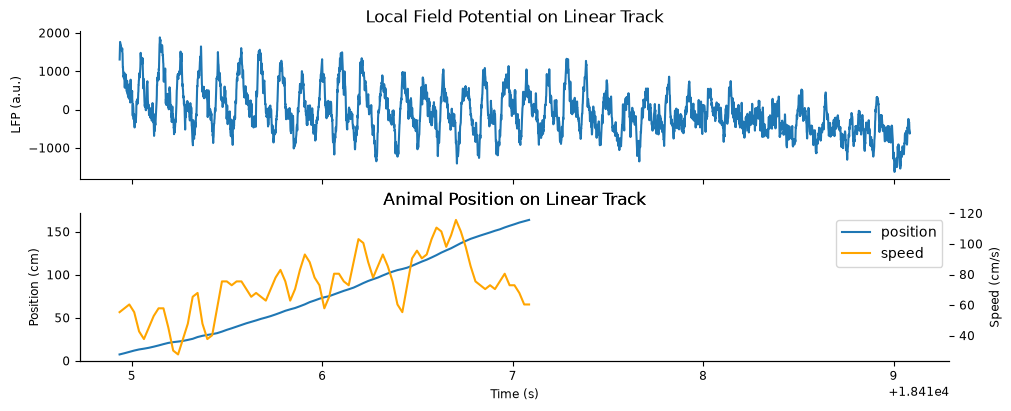

In [18]:
fig, axs = plt.subplots(2, 1, constrained_layout=True, figsize=(10, 4), sharex=True)

# plot LFP
axs[0].plot(ex_lfp)
axs[0].set_title("Local Field Potential on Linear Track")
axs[0].set_ylabel("LFP (a.u.)")

# plot animal's position
l1, = axs[1].plot(ex_position)
axs[1].set_title("Animal Position on Linear Track")
axs[1].set_ylabel("Position (cm)") 
axs[1].set_xlabel("Time (s)");

# plot animal's speed
ax = axs[1].twinx()
l2, = ax.plot(ex_speed, c="orange")
ax.set_title("Animal Position on Linear Track")
ax.set_ylabel("Speed (cm/s)")
axs[1].legend([l1,l2], ["position","speed"])

In [19]:
fig.savefig("../../../_static/_check_figs/pc-01.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-01.png)
:::
</div>

<div class="render-all"> 

There is a strong theta oscillation dominating the LFP while the animal runs down the track; this oscillation is weaker after the run is complete.

</div>

## Part 2: 1D neural tuning and model fitting
### Computing 1D tuning curves: place fields

<div class="render-all">

Next, we'll compute place selectivity of each unit. We can find place firing preferences of each unit by using the function [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves).

We'll filter for units that fire at least 1 Hz and at most 10 Hz when the animal is running forward along the linear track. This will select for units that are active during our window of interest and eliminate putative interneurons (i.e. fast-firing inhibitory neurons that don't usually have place selectivity). Afterwards, we'll compute the tuning curves for these sub-selected units over position.

</div>

#### 4. Restrict `spikes` to `forward_ep` and select for units whose rate is at least 1 Hz and at most 10 Hz

<div class="render-user">
```{code-cell} ipython3
# save the filtered spikes in the following variable
good_spikes = 
```
</div>

In [20]:
good_spikes = spikes[(spikes.restrict(forward_ep).rate >= 1) & (spikes.restrict(forward_ep).rate <= 10)]

#### 5. Compute tuning curves with respect to `position` for units in `good_spikes`.

<div class="render-all">

- Use 50 position bins
- Name the feature `"position"` using the optional argument `feature_names`

</div>

<div class="render-user">
```{code-cell} ipython3
place_fields = 
```
</div>

In [21]:
place_fields = nap.compute_tuning_curves(good_spikes, position, 50, feature_names=["position"])

<div class="render-all">

This function returns tuning curves as an `xarray.DataArray`, with coordinates for unit (first dimension) and position (second dimension). An `xarray.DataArray` object provides convenient tools for plotting and other manipulations, and it scales well for tuning curves with more than 1 feature. 

</div>

:::{admonition} Tip
:class: tip render-all

The reason [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves) returns a `xarray.DataArray` and not a Pynapple object is because the array elements no longer correspond to *time*, which Pynapple objects require.
:::

<div class="render-all">

We can use the `xarray.DataArray` `plot` method to easily plot each unit, focusing on three example units.

</div>

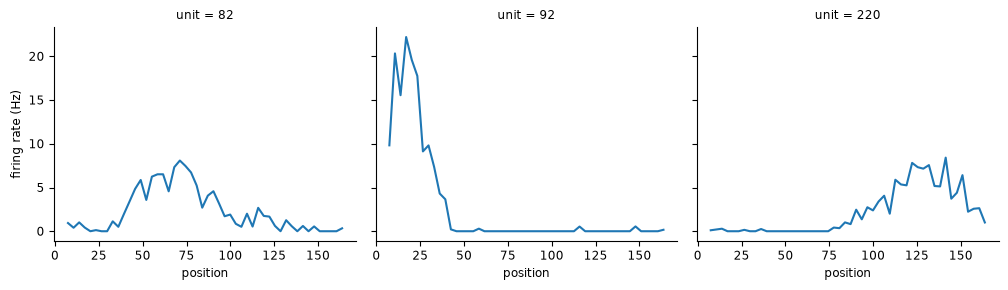

In [22]:
neurons = [82, 92, 220]
p = place_fields.sel(unit=neurons).plot(x="position", col="unit")
p.set_ylabels("firing rate (Hz)")

In [23]:
p.fig.savefig("../../../_static/_check_figs/pc-02.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-02.png)
:::
</div>

<div class="render-all">
    
We can see clear spatial selectivity in these example units, where firing rate peaks at specific positions along the track.

Let's repeat this exercise, but instead compute tuning curves as a function of *speed* instead of position.

</div>

#### 6. Compute tuning curves with respect to `speed` for units in `good_spikes`.

<div class="render-all">

- Use 30 speed bins
- Name the feature `"speed"` using the optional argument `feature_names`

</div>

<div class="render-user">
```{code-cell} ipython3
speed_fields = 
```
</div>

In [24]:
speed_fields = nap.compute_tuning_curves(spikes, speed, bins=30, epochs=speed.time_support, feature_names=["speed"])

<div class="render-all">
    
Let's compare the position tuning with the speed tuning of select neurons.

</div>

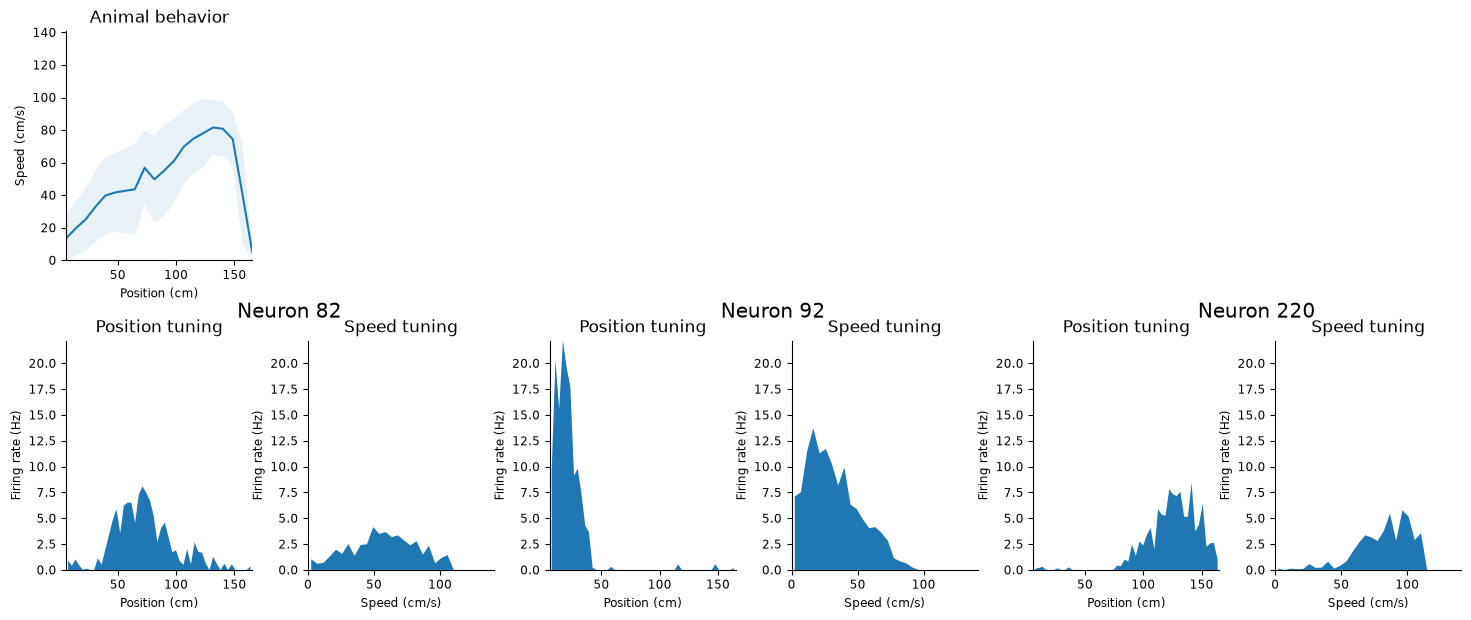

In [25]:
fig = workshop_utils.plot_position_speed(position, speed, place_fields.sel(unit=neurons), speed_fields.sel(unit=neurons), neurons);

In [26]:
fig.savefig("../../../_static/_check_figs/pc-03.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-03.png)
:::
</div>


<div class="render-all">

In these example units, and we see that the speed and position tuning are highly correlated. How can we disentangle which variable is responsible for driving neural activity? This is where NeMoS comes in handy: GLMs can help us model responses to multiple, potentially correlated predictors. 

</div>

### Estimating tuning curves using a population GLM

<div class="render-all">

The goal of the remaining exercises in this section is to fit a PopulationGLM including both position and speed as predictors, and check if this model accurately captures the tuning curves of the neurons.

</div>

#### 7. Compute observations by counting spikes, using the pynapple method `count`, on our `TsGroup` of spike times, `good_spikes`.

<div class="render-all">

- For speed later on, only compute `count` on our example units by indexing `good_spikes` with `neurons`
- Use a `bin_size` of 10 ms (0.01s)
- Pass `forward_ep` as the optional argument `ep` to make sure we're only counting during forward runs.

</div>

<div class="render-user">
```{code-cell} ipython3
bin_size = 
counts = 
```
</div>

In [27]:
bin_size = 0.01
counts = good_spikes[neurons].count(bin_size, ep=forward_ep)

<div class="render-all">

By using this bin size for spike counts, `counts` will have a much higher sampling rate, and therefore have more data points, than our features, `position` and `speed`. We need to upsample our features to match the number of time points in `counts` in order to create a design matrix of the correct size to fit the model. We can achieve this by using the pynapple object method [`interpolate`](https://pynapple.org/generated/pynapple.Tsd.interpolate.html). This method will linearly interpolate new position and speed samples between existing samples at timestamps given by another pynapple object, in our case by `counts`.

</div>

#### 8. Upsample `position` and `speed` using the pynapple method [`interpolate`](https://pynapple.org/generated/pynapple.Tsd.interpolate.html) with the time stamps from `counts`.

<div class="render-user">
```{code-cell} ipython3
up_position = 
up_speed = 
```
</div>

In [28]:
up_position = position.interpolate(counts)
up_speed = speed.interpolate(counts)

As we've seen before, we will use basis objects to represent the input values.  In previous tutorials, we've used the `Conv` basis objects to represent the time-dependent effects we were looking to capture. Here, we're trying to capture the non-linear relationship between our input variables and firing rate, so we want the `Eval` objects. In these circumstances, you should look at the tuning you're trying to capture and compare to the [basis kernels (visualized in NeMoS docs)](https://nemos.readthedocs.io/en/latest/background/basis/README.html#): you want your tuning to be capturable by a linear combination of them.

In this case, several of these would probably work; here we will use [`BSplineEval`](https://nemos.readthedocs.io/en/latest/generated/basis/nemos.basis.BSplineEval.html#nemos.basis.BSplineEval). Since we have two different inputs, we'll need two separate basis objects.


(basis-eval-place-cells-full)=
#### 9. Instantiate the basis by doing the following:

<div class="render-all">

- Create a separate basis object for each model input (speed and position).
- Use `BSplineEval` basis with, using 12 basis functions for position and 6 basis functions for speed.
- Provide a label for each basis ("position" and "speed").

We'll use a helper function to visualize the resulting basis functions.

</div>

<div class="render-user">
```{code-cell} ipython3
position_basis = 
speed_basis = 
workshop_utils.plot_pos_speed_bases(position_basis, speed_basis)
```
</div>

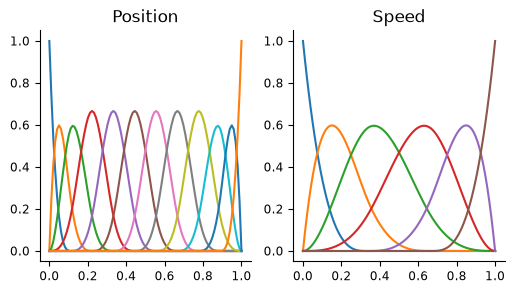

In [29]:
position_basis = nmo.basis.BSplineEval(n_basis_funcs=12, label="position")
speed_basis = nmo.basis.BSplineEval(n_basis_funcs=6, label="speed")
fig = workshop_utils.plot_pos_speed_bases(position_basis, speed_basis)

In [30]:
fig.savefig("../../../_static/_check_figs/pc-04.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-04.png)
:::
</div>

<div class="render-all">
    
However, now we have an issue: in all our previous examples, we had a single basis object, which took a single input to produce a single array which we then passed to the `GLM` object as the design matrix. What do we do when we have multiple basis objects?

To do this, we can use [NeMoS basis composition](https://nemos.readthedocs.io/en/latest/background/basis/plot_02_ND_basis_function.html), where you can add the two bases together and obtain a new additive basis. We can similarly call `compute_features` on this additive basis, passing both position and speed, to obtain the same design matrix. For people familiar with NumPy, this is equivalent to calling `basis.compute_features()` for each basis separately and then [concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html) the outputs.

</div>

#### 10. Create an additive basis by adding together `position_basis` and `speed_basis`.

<div class="render-user">
```{code-cell} ipython3
additive_basis = 
```
</div>

In [31]:
additive_basis = position_basis + speed_basis

#### 11. Create a design matrix by passing `up_position` and `up_speed` to the basis method `compute_features`

<div class="render-all">

- Make sure the features are passed in the same order that the basis objects were added together!

</div>

<div class="render-user">
```{code-cell} ipython3
X = 
```
</div>

In [32]:
X = additive_basis.compute_features(up_position, up_speed)
X

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Time (s)                   0          1           2            3    4  ...
------------------  --------  ---------  ----------  -----------  ---  -----
18193.603802655     0.907242  0.0912531  0.00149924  5.42445e-06    0  ...
18193.613802655     0.883494  0.114102   0.00239357  1.10303e-05    0  ...
18193.623802655     0.860164  0.136327   0.00348961  1.95736e-05    0  ...
18193.633802655     0.823097  0.171168   0.00569461  4.13443e-05    0  ...
18193.643802655002  0.786239  0.205202   0.00848273  7.61954e-05    0  ...
18193.653802655     0.75855   0.230345   0.0109914   0.00011358     0  ...
18193.663802655003  0.744462  0.24299    0.0124107   0.000137028    0  ...
...                                                                    ...
20123.332682821     0         0          0           0              0  ...
20123.342682821     0         0          0           0              0  ...
20123.352682821     0         0          0           0              0  ...
20123.362682821     0  

<div class="render-all">

Notice that, since we passed pynapple objects to the basis object, we got a pynapple object back, preserving the time stamps. Additionally, `X` has the same number of time points as our input position and speed, but 18 columns. The columns come from  `n_basis_funcs` from each basis (12 for position, 6 for speed).

As we've done before, we can now use the Poisson GLM from NeMoS to learn the combined model.

</div>

#### 12. Fit a GLM by doing the following:

<div class="render-all">

- Initialize `PopulationGLM`
- Use the "LBFGS" solver and pass `{"tol": 1e-12}` to `solver_kwargs`.
- Fit the data, passing the design matrix `X` and spike counts `counts` to the glm object.

</div>

<div class="render-user">
```{code-cell} ipython3
# define the model
glm =
# fit
glm.fit(
```
</div>

In [33]:
glm = nmo.glm.PopulationGLM(
    solver_kwargs={"tol": 1e-12},
    solver_name="LBFGS",
)
glm.fit(X, counts)

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/.venv/lib/python3.12/site-packages/nemos/glm/glm.py:841: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f82a80defc0>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{'tol': 1e-12}
,regularizer_strength,None
,feature_mask,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float32](18, 3)",Array([[ 0.1...dtype=float32)
dof_resid_,"ArrayImpl[float32](3,)",Array([19219....dtype=float32)


<div class="render-all">

Let's check first if our model can accurately predict the tuning curves we displayed above. We can use the [`predict`](https://nemos.readthedocs.io/en/latest/generated/glm/nemos.glm.GLM.predict.html#nemos.glm.GLM.predict) function of NeMoS and then compute new tuning curves using pynapple. 

</div>

#### 13. Use [`predict`](https://nemos.readthedocs.io/en/latest/generated/glm/nemos.glm.GLM.predict.html#nemos.glm.GLM.predict) to calculated the predicted firing rate of our model. Use the predicted rate to compute predicted tuning curves using [`nap.compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves).

<div class="render-all">

- Remember to convert the predicted firing rate to spikes per second!
- Use 50 bins for position tuning curves and 30 bins for speed tuning curves.

</div>

<div class="render-user">
```{code-cell} ipython3
# predict the model's firing rate
predicted_rate =
# compute the position and speed tuning curves using the predicted firing rate.
glm_tuning_pos = 
glm_tuning_speed = 
```
</div>

In [34]:
# predict the model's firing rate
predicted_rate = glm.predict(X) / bin_size

# same shape as the counts we were trying to predict
print(predicted_rate.shape, counts.shape)

# compute the position and speed tuning curves using the predicted firing rate.
glm_tuning_pos = nap.compute_tuning_curves(predicted_rate, position, bins=50, epochs=position.time_support, feature_names=["position"])
glm_tuning_speed = nap.compute_tuning_curves(predicted_rate, speed, bins=30, epochs=speed.time_support, feature_names=["speed"])

(19237, 3) (19237, 3)


<div class="render-all">

We can plot the results to compare the model and data tuning curves.

</div>

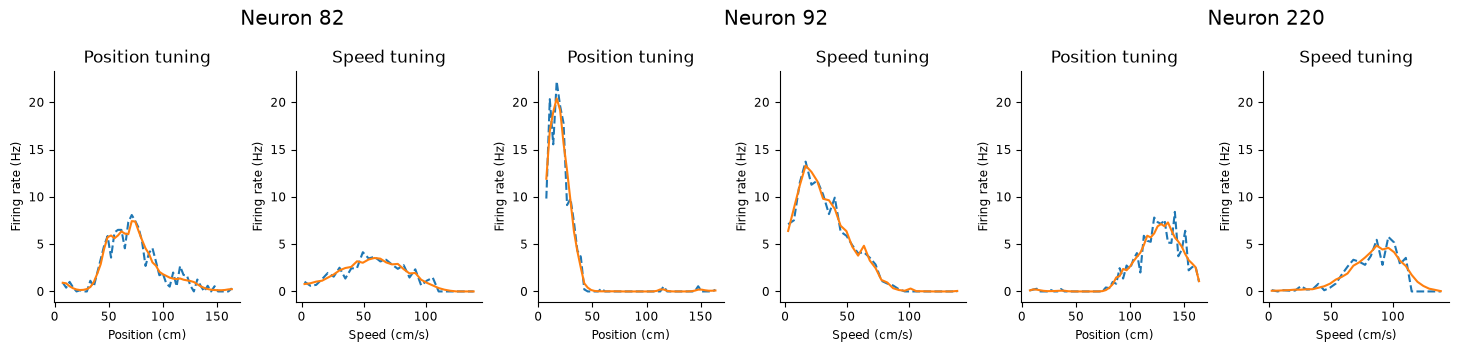

In [35]:
fig = workshop_utils.plot_position_speed_tuning(place_fields.sel(unit=neurons), speed_fields.sel(unit=neurons), glm_tuning_pos, glm_tuning_speed);

In [36]:
fig.savefig("../../../_static/_check_figs/pc-05.png", bbox_inches="tight")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/pc-05.png)
:::
</div>

<div class="render-all">

We can see that this model does a good job capturing both the position and the speed. 

</div>